In [2]:
# PART 1: THE TENSOR CLASS
#
# WHAT IS THIS?
#   A tiny homemade version of what PyTorch Tensors do:
#     1) store numbers (data)
#     2) remember HOW those numbers were computed (a graph of ops)
#     3) when you call .backward(), automatically compute gradients
#        (how much each input should change to increase/decrease the result)
#
# WHY?
#   Training a neural net = "nudge weights opposite the gradient."
#   This Tensor class is the engine that finds those gradients for you
#   using the chain rule (backpropagation).
#
# Kid picture:
#   Forward: mix ingredients → get a cake score
#   Backward: figure out "if I change sugar a tiny bit, how does the score change?"

# Basic Tensor with Gradient Tracking

import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict


def _reduce_grad(grad, shape):
    """Sum away axes that were introduced by NumPy broadcasting.
    Example: bias b shape (1,) added to (4,1) → incoming grad (4,1) must become (1,).
    """
    grad = np.asarray(grad, dtype=np.float64)
    # Extra leading dims (rare here, but safe)
    while grad.ndim > len(shape):
        grad = grad.sum(axis=0)
    # Dims that were size-1 and got expanded
    for axis, size in enumerate(shape):
        if size == 1 and grad.shape[axis] > 1:
            grad = grad.sum(axis=axis, keepdims=True)
    return grad.reshape(shape)


class Tensor:
    """
    Minimal Tensor with automatic differentiation
    (inspired by micrograd / PyTorch).
    """
    def __init__(self, data, children=(), op='', requires_grad=False):
        self.data = np.array(data, dtype=np.float64)  # the actual numbers
        # grad = "sensitivity": how the final loss changes if this tensor changes
        self.grad = np.zeros_like(self.data) if requires_grad else None
        self.requires_grad = requires_grad            # True for weights we want to learn
        self._backward = lambda: None                 # function that pushes grad to parents
        self._prev = set(children)                    # tensors this one was built from
        self._op = op                                 # '+', '*', 'ReLU', ... (for debugging)

    @property
    def shape(self):
        # Match NumPy/PyTorch: t.shape instead of t.data.shape
        return self.data.shape

    def __repr__(self):
        return f"Tensor(data={self.data}, grad={self.grad}, op='{self._op}')"

    def backward(self):
        # 1) Order all nodes so parents come before children (topological sort)
        #    Then we walk REVERSED: children → parents (true backpropagation order)
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        # 2) Seed: d(final)/d(final) = 1
        self.grad = np.ones_like(self.data)

        # 3) Apply each node's local chain-rule rule
        for v in reversed(topo):
            v._backward()

    # --- Basic arithmetic ---
    # Pattern for every op:
    #   - compute forward value into `out`
    #   - define _backward that sends out.grad back to inputs using the derivative

    def __add__(self, other):
        # c = a + b  →  dc/da = 1, dc/db = 1
        other = other if isinstance(other, Tensor) else Tensor(other)
        out = Tensor(
            self.data + other.data,
            (self, other),
            '+',
            requires_grad=self.requires_grad or other.requires_grad,
        )
        def _backward():
            if self.requires_grad:
                self.grad += _reduce_grad(out.grad, self.data.shape)
            if other.requires_grad:
                other.grad += _reduce_grad(out.grad, other.data.shape)
        out._backward = _backward
        return out

    def __mul__(self, other):
        # c = a * b  →  dc/da = b, dc/db = a
        other = other if isinstance(other, Tensor) else Tensor(other)
        out = Tensor(
            self.data * other.data,
            (self, other),
            '*',
            requires_grad=self.requires_grad or other.requires_grad,
        )
        def _backward():
            if self.requires_grad:
                self.grad += _reduce_grad(other.data * out.grad, self.data.shape)
            if other.requires_grad:
                other.grad += _reduce_grad(self.data * out.grad, other.data.shape)
        out._backward = _backward
        return out

    def __matmul__(self, other):
        """Matrix multiply: self @ other  (used for neural net layers)"""
        other = other if isinstance(other, Tensor) else Tensor(other)
        out = Tensor(
            self.data @ other.data,
            (self, other),
            '@',
            requires_grad=self.requires_grad or other.requires_grad,
        )
        def _backward():
            if self.requires_grad:
                # dL/d(self) = dL/d(out) @ other.T
                self.grad += out.grad @ other.data.T
            if other.requires_grad:
                # dL/d(other) = self.T @ dL/d(out)
                other.grad += self.data.T @ out.grad
        out._backward = _backward
        return out

    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)

    def __truediv__(self, other):
        return self * (other ** -1)

    def __pow__(self, power):
        # c = a ** p  →  dc/da = p * a**(p-1)
        assert isinstance(power, (int, float))
        out = Tensor(
            self.data ** power,
            (self,),
            f'**{power}',
            requires_grad=self.requires_grad,
        )
        def _backward():
            if self.requires_grad:
                self.grad += power * (self.data ** (power - 1)) * out.grad
        out._backward = _backward
        return out

    # --- Activations (nonlinear "on/off" transforms) ---

    def relu(self):
        # ReLU: keep positives, zero out negatives
        # derivative is 1 if x>0 else 0
        out = Tensor(np.maximum(0, self.data), (self,), 'ReLU', requires_grad=self.requires_grad)
        def _backward():
            if self.requires_grad:
                self.grad += (self.data > 0) * out.grad
        out._backward = _backward
        return out

    def sigmoid(self):
        # Squash any number into (0, 1) — useful for probabilities
        s = 1 / (1 + np.exp(-self.data))
        out = Tensor(s, (self,), 'Sigmoid', requires_grad=self.requires_grad)
        def _backward():
            if self.requires_grad:
                self.grad += s * (1 - s) * out.grad
        out._backward = _backward
        return out

    def tanh(self):
        # Squash into (-1, 1)
        t = np.tanh(self.data)
        out = Tensor(t, (self,), 'Tanh', requires_grad=self.requires_grad)
        def _backward():
            if self.requires_grad:
                self.grad += (1 - t ** 2) * out.grad
        out._backward = _backward
        return out

    # --- Reductions (many numbers → one number; needed for a scalar loss) ---

    def sum(self):
        out = Tensor(np.sum(self.data), (self,), 'sum', requires_grad=self.requires_grad)
        def _backward():
            if self.requires_grad:
                # sum's gradient spreads equally back to every element
                self.grad += np.ones_like(self.data) * out.grad
        out._backward = _backward
        return out

    def mean(self):
        n = self.data.size
        out = Tensor(np.mean(self.data), (self,), 'mean', requires_grad=self.requires_grad)
        def _backward():
            if self.requires_grad:
                self.grad += np.ones_like(self.data) * (out.grad / n)
        out._backward = _backward
        return out


# --- Quick test: c = a*b + a ---
# Math: dc/da = b + 1 = 4,  dc/db = a = 2
a = Tensor([2.0], requires_grad=True)
b = Tensor([3.0], requires_grad=True)
c = a * b + a
c.backward()
print("c =", c.data)
print("a.grad =", a.grad, "(should be b+1 = 4)")
print("b.grad =", b.grad, "(should be a = 2)")
# If those match, forward + backward graph is working.

# You just built the core of PyTorch. 
# Every operation records a _backward closure that computes local gradients via the chain rule. 
# Calling .backward() triggers the whole graph.

c = [8.]
a.grad = [4.] (should be b+1 = 4)
b.grad = [2.] (should be a = 2)


In [6]:
# Testing the Autograd Engine
#
# Two checks:
#   1) Scalar graph: y = (x1 + x2) * x3  → known hand-computed grads
#   2) Matrix graph: C = A @ B, loss = sum(C) → check A.grad shape/formula
#
# If both pass, + * @ and backward() are trustworthy for building layers later.

# --- Test 1: scalar expression ---
# y = (x1 + x2) * x3
# With x1=1, x2=2, x3=3 → y = (1+2)*3 = 9
#
# Chain rule:
#   dy/dx1 = x3 = 3          (x1 only appears inside the sum, then * x3)
#   dy/dx2 = x3 = 3
#   dy/dx3 = (x1+x2) = 3
x1 = Tensor([1.0], requires_grad=True)
x2 = Tensor([2.0], requires_grad=True)
x3 = Tensor([3.0], requires_grad=True)

y = (x1 + x2) * x3
y.backward()  # fill .grad on x1, x2, x3

print("y =", y.data)  # expect 9
print("x1.grad:", x1.grad, "(dy/dx1 = x3 = 3)")
print("x2.grad:", x2.grad, "(dy/dx2 = x3 = 3)")
print("x3.grad:", x3.grad, "(dy/dx3 = x1+x2 = 3)")

# --- Test 2: matrix multiplication gradients ---
# A is (2,3), B is (3,2) → C = A @ B is (2,2)
# loss = sum of all entries of C  →  d(loss)/dC = ones(2,2)
#
# From matmul backward:
#   dL/dA = (dL/dC) @ B.T   → shape (2,2)@(2,3) = (2,3)  matches A
#   dL/dB = A.T @ (dL/dC)   → shape (3,2)@(2,2) = (3,2)  matches B
A = Tensor(np.random.randn(2, 3), requires_grad=True)
B = Tensor(np.random.randn(3, 2), requires_grad=True)
C = A @ B       # forward matmul
loss = C.sum()  # scalar so backward has a single starting grad
loss.backward()

print("\nMatrix grad test:")
# .data.shape always works (NumPy). Tensor also has .shape @property if cell 0 was run.
print("A.shape:", A.data.shape, "A.grad.shape:", A.grad.shape)
print("B.shape:", B.data.shape, "B.grad.shape:", B.grad.shape)
# True means our A.grad matches the analytic formula ones @ B.T
print("Gradient check A:", np.allclose(A.grad, np.ones((2, 2)) @ B.data.T))

# Critical: Notice how matrix multiplication gradients involve transposes. This is why shape errors plague neural network code. 
# Knowing the rule dL/dA = dL/dC @ B^T prevents most bugs.

y = [9.]
x1.grad: [3.] (dy/dx1 = x3 = 3)
x2.grad: [3.] (dy/dx2 = x3 = 3)
x3.grad: [3.] (dy/dx3 = x1+x2 = 3)

Matrix grad test:
A.shape: (2, 3) A.grad.shape: (2, 3)
B.shape: (3, 2) B.grad.shape: (3, 2)
Gradient check A: True


In [8]:
# PART 2: NEURAL NETWORK LAYERS
#
# WHAT IS THIS?
#   Building blocks that stack into a neural net — same idea as torch.nn.
#
#   Module     = base class ("any layer")
#   Linear     = y = x @ W + b   (the classic fully-connected layer)
#   ReLU / Sigmoid = nonlinear activations (so the net can learn curves, not only lines)
#   Sequential = pipe layers one after another: x → L1 → L2 → ...
#
# Kid picture:
#   Linear = mix ingredients with a recipe (weights W, bias b)
#   ReLU   = throw away negative tastes (keep only useful signal)
#   Sequential = assembly line of those steps

# Linear Layer, ReLU, Sequential

class Module:
    """Base class for all layers (like torch.nn.Module)."""
    def parameters(self):
        # Learnable Tensors (weights/biases). Default: none.
        return []

    def zero_grad(self):
        # Before each training step, clear old gradients
        # (grads accumulate with += in our Tensor backward)
        for p in self.parameters():
            p.grad = np.zeros_like(p.data)


class Linear(Module):
    """Fully connected layer: output = x @ W + b"""
    def __init__(self, in_features, out_features):
        # W shape: (in_features, out_features)
        # He/Xavier-ish scale: * sqrt(2/in) keeps initial values from exploding
        self.W = Tensor(
            np.random.randn(in_features, out_features) * np.sqrt(2.0 / in_features),
            requires_grad=True,  # we want gradients so we can learn W
        )
        self.b = Tensor(np.zeros((1, out_features)), requires_grad=True)  # row vector: broadcasts over batch

    def forward(self, x):
        # x: (batch, in_features)  →  (batch, out_features)
        return x @ self.W + self.b

    def parameters(self):
        return [self.W, self.b]


class ReLU(Module):
    """Activation: max(0, x) — zeros out negatives, passes positives."""
    def forward(self, x):
        return x.relu()


class Sigmoid(Module):
    """Activation: squash to (0, 1) — often used for binary probability output."""
    def forward(self, x):
        return x.sigmoid()


class Sequential(Module):
    """Stack layers in order. forward runs them left → right."""
    def __init__(self, *layers):
        self.layers = layers  # e.g. Linear(...), ReLU(), Linear(...)

    def forward(self, x):
        for layer in self.layers:
            x = layer.forward(x)  # output of one becomes input of next
        return x

    def parameters(self):
        # Collect ALL learnable weights from every sub-layer
        # (optimizer will loop over this list)
        params = []
        for layer in self.layers:
            params.extend(layer.parameters())
        return params


# Example (conceptually):
#   model = Sequential(
#       Linear(2, 8),
#       ReLU(),
#       Linear(8, 1),
#       Sigmoid(),
#   )
#   y_hat = model.forward(x)   # prediction
#   # then loss.backward(); update each p in model.parameters()


In [11]:
# Loss Functions
#
# WHAT IS A LOSS?
#   One number that means "how wrong is the model?"
#   Training = change weights so this number goes DOWN.
#
#   After forward:  loss = some_loss(prediction, truth)
#   Then:           loss.backward()  → fills .grad on all weights
#
# Which loss when?
#   mse_loss              → predict a NUMBER (regression), e.g. house price
#   binary_cross_entropy  → predict YES/NO probability (0 or 1)
#   cross_entropy_loss    → predict ONE OF MANY classes (cat/dog/bird...)

def mse_loss(y_pred, y_true):
    """Mean Squared Error — average of (prediction - truth)^2.
    Big mistakes get punished harder because of the square.
    """
    return ((y_pred - y_true) ** 2).mean()


def binary_cross_entropy(y_pred, y_true):
    """Binary Cross-Entropy for probabilities in (0, 1).

    Idea:
      if truth=1, punish low probability  →  -log(p)
      if truth=0, punish high probability →  -log(1-p)

    Needs .log() on Tensor (patched onto the class below).
    """
    # Note: an earlier clip-into-new-Tensor approach would break the graph;
    # we rely on log() clipping internally instead.
    return -(y_true * y_pred.log() + (1 - y_true) * (1 - y_pred).log()).mean()


# --- Add log() to Tensor so BCE can backprop through it ---
# d/dx log(x) = 1/x
def tensor_log(self):
    out = Tensor(
        np.log(np.clip(self.data, 1e-7, None)),  # clip avoids log(0)
        (self,),
        'log',
        requires_grad=self.requires_grad,
    )
    def _backward():
        if self.requires_grad:
            self.grad += (1.0 / (self.data + 1e-7)) * out.grad
    out._backward = _backward
    return out

Tensor.log = tensor_log  # monkey-patch: now every Tensor has .log()


def cross_entropy_loss(logits, y_true_indices):
    """Multi-class cross-entropy from raw scores (logits).

    Steps:
      1) Softmax logits → probabilities that sum to 1 per row
      2) Pick probability of the CORRECT class
      3) loss = -mean(log(that probability))
         (if correct class has prob≈1, loss≈0; if tiny, loss is large)

    Numerically stable trick: subtract max(logit) before exp (same as earlier softmax tip).

    Backward uses the known shortcut:
      dL/d(logits) = (softmax_probs - one_hot_labels) / batch_size
    """
    n = logits.data.shape[0]  # batch size

    # Stable softmax
    shifted = logits.data - np.max(logits.data, axis=1, keepdims=True)
    exp_shifted = np.exp(shifted)
    probs = exp_shifted / np.sum(exp_shifted, axis=1, keepdims=True)

    # -log(prob of true class), averaged
    log_probs = np.log(probs[np.arange(n), y_true_indices] + 1e-7)
    loss = -np.mean(log_probs)

    # Wire into our Tensor graph so loss.backward() reaches logits
    out = Tensor(loss, requires_grad=logits.requires_grad)
    out._prev = {logits}
    out._softmax_probs = probs
    out._y_true_indices = y_true_indices

    def _backward():
        if logits.requires_grad:
            grad = probs.copy()
            grad[np.arange(n), y_true_indices] -= 1  # subtract 1 at the true class
            grad /= n
            logits.grad += grad * out.grad

    out._backward = _backward
    return out


# Quick mental check:
#   perfect prediction → loss near 0
#   confident but wrong → loss large
#   loss.backward() → tells Linear weights how to fix the next guess

# Note: We'll train on MNIST using a simpler approach: we'll manually implement the full network's backward pass. 
# That's actually more educational and you'll see exactly how cross-entropy gradients work. 
# In practice, our Tensor class can handle it, but for clarity we'll build a dedicated training loop with explicit gradient computation.

Predictions after training:
[[0.]
 [1.]
 [1.]
 [0.]]
Loss curve:


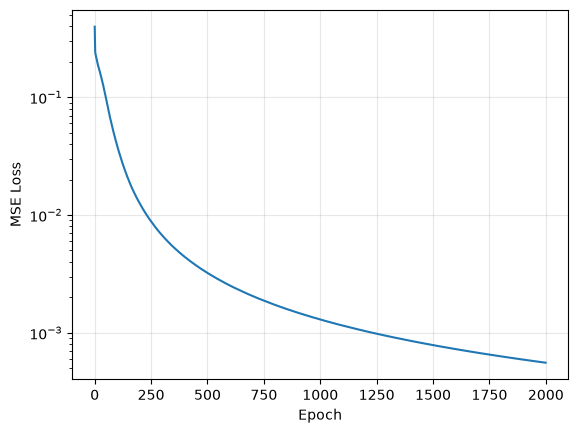

In [17]:
# PART 3: TRAINING ON XOR (Sanity Check)
#
# WHAT ARE WE DOING?
#   Prove our mini framework can LEARN a nonlinear pattern.
#   XOR truth table:
#     (0,0) → 0
#     (0,1) → 1
#     (1,0) → 1
#     (1,1) → 0
#   A single straight line CAN'T separate XOR. A 2-layer net with ReLU can.
#
# TRAINING LOOP (same as real deep learning):
#   1) Forward  → predict
#   2) Loss     → how wrong
#   3) zero_grad → clear old grads
#   4) backward → fill .grad on weights
#   5) update   → weights -= lr * grad
#   Repeat many epochs.
#
# WHAT THE PLOT SHOULD SHOW:
#   Loss falling (log scale). Predictions rounding to [[0],[1],[1],[0]].

# IMPORTANT: If you see a broadcast ValueError on loss.backward(),
# re-run the PART 1 Tensor cell first (or just run this cell — it re-applies the fix below).

# --- Broadcast-safe + and * (bias shape (1,) vs batch (4,1)) ---
# When we do  y = x@W + b, NumPy expands b across the batch.
# On backward, we must SUM that expanded grad back down to b's real shape.
def _reduce_grad(grad, shape):
    grad = np.asarray(grad, dtype=np.float64)
    while grad.ndim > len(shape):
        grad = grad.sum(axis=0)
    for axis, size in enumerate(shape):
        if size == 1 and grad.shape[axis] > 1:
            grad = grad.sum(axis=axis, keepdims=True)
    return grad.reshape(shape)

def _add_broadcast_safe(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(
        self.data + other.data,
        (self, other),
        '+',
        requires_grad=self.requires_grad or other.requires_grad,
    )
    def _backward():
        if self.requires_grad:
            self.grad += _reduce_grad(out.grad, self.data.shape)
        if other.requires_grad:
            other.grad += _reduce_grad(out.grad, other.data.shape)
    out._backward = _backward
    return out

def _mul_broadcast_safe(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(
        self.data * other.data,
        (self, other),
        '*',
        requires_grad=self.requires_grad or other.requires_grad,
    )
    def _backward():
        if self.requires_grad:
            self.grad += _reduce_grad(other.data * out.grad, self.data.shape)
        if other.requires_grad:
            other.grad += _reduce_grad(self.data * out.grad, other.data.shape)
    out._backward = _backward
    return out

# Re-bind onto Tensor so this cell works even if Part 1 wasn't re-run after the fix
Tensor.__add__ = _add_broadcast_safe
Tensor.__mul__ = _mul_broadcast_safe

# --- Data ---
np.random.seed(0)  # same starting weights every run
X_xor = Tensor(np.array([[0., 0.], [0., 1.], [1., 0.], [1., 1.]]), requires_grad=False)
y_xor = Tensor(np.array([[0.], [1.], [1.], [0.]]), requires_grad=False)

# --- Model: inputs(2) → hidden(8)+ReLU → output(1)+Sigmoid ---
# ReLU = nonlinear “bend”; Sigmoid = output probability-ish in (0,1)
model = Sequential(
    Linear(2, 8),
    ReLU(),
    Linear(8, 1),
    Sigmoid(),
)

# --- Train ---
lr = 0.5          # step size for weight updates
n_epochs = 2000   # how many times we see the full XOR table
losses = []
for epoch in range(n_epochs):
    # 1) Forward: 4 predictions (one per XOR row)
    y_pred = model.forward(X_xor)

    # 2) How wrong? (MSE works fine on these 0/1 targets)
    loss = mse_loss(y_pred, y_xor)
    losses.append(loss.data)

    # 3) Clear grads from last step (they accumulate with +=)
    model.zero_grad()

    # 4) Backprop: fill p.grad for every weight/bias
    loss.backward()

    # 5) SGD step: nudge each parameter opposite its gradient
    for p in model.parameters():
        p.data -= lr * p.grad

# --- Results ---
print("Predictions after training:")
print(y_pred.data.round())  # expect [[0],[1],[1],[0]]
print("Loss curve:")
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.yscale('log')  # easier to see the drop
plt.grid(True, alpha=0.3)
plt.show()
# Falling curve + correct rounded preds ⇒ framework can learn XOR. Success.

# If your framework works, the loss will drop and predictions become [[0],[1],[1],[0]]. 
# If it doesn't, you have a bug. Common issues: forgetting to zero gradients, wrong sigmoid backward, or not clipping log.

Loading MNIST...
X_train: (56000, 784), y_train: (56000,)
X_test: (14000, 784), y_test: (14000,)


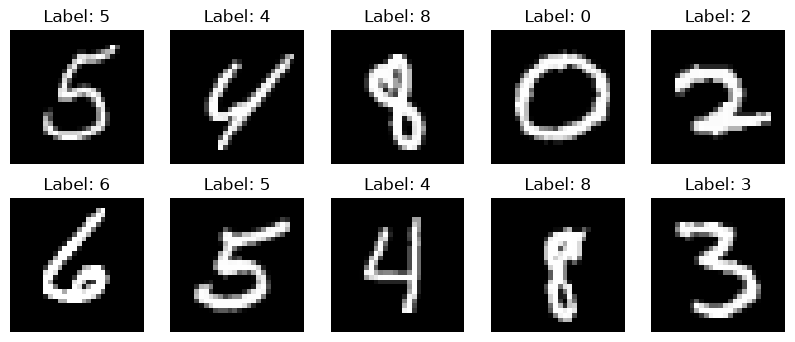

In [30]:
# PART 4: MNIST CLASSIFIER
# MNIST = 70,000 handwritten digit images (0–9), each 28×28 = 784 pixels.

# Load and Preprocess MNIST
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

print("Loading MNIST...")
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, parser='auto')

# Convert to NumPy (OpenML often returns pandas DataFrame/Series)
X = np.asarray(X, dtype=np.float32) / 255.0   # pixels → [0, 1]
y = np.asarray(y, dtype=np.int32)             # MUST be ndarray, not pandas Series
# (pandas y_train[i] looks up by label index → KeyError after train_test_split)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

# Show a few digits
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(X_train[i].reshape(28, 28), cmap='gray')
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis('off')
plt.show()


In [31]:
# Two-Layer MLP with Explicit Backward (Most Educational)
#
# WHAT WE'RE BUILDING:
#   A digit reader: image (784 pixels) → hidden layer → 10 scores (digits 0–9).
#
#   Architecture:
#     X (N×784)
#       → Linear (W1,b1) → ReLU
#       → Linear (W2,b2) → Softmax → probabilities for 10 digits
#
# WHY "EXPLICIT" BACKWARD?
#   Instead of our Tensor autograd, we write the gradients by hand
#   so you can SEE how softmax+cross-entropy and ReLU backprop work.
#
# Later cells: train this net, then check test accuracy.

class TwoLayerNet:
    def __init__(self, input_size, hidden_size, output_size):
        # He init: random weights scaled so signals don't explode/vanish at start
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2.0 / input_size)
        self.b1 = np.zeros(hidden_size)
        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2.0 / hidden_size)
        self.b2 = np.zeros(output_size)

        self.params = [self.W1, self.b1, self.W2, self.b2]
        self.grads = [np.zeros_like(p) for p in self.params]

    def forward(self, X):
        """X: (N, 784) → probs: (N, 10)  each row sums to 1"""
        self.X = X
        self.z1 = X @ self.W1 + self.b1          # pre-activation hidden
        self.a1 = np.maximum(0, self.z1)         # ReLU: keep positives only
        self.z2 = self.a1 @ self.W2 + self.b2    # 10 raw scores (logits)

        # Stable softmax → probabilities
        shifted = self.z2 - np.max(self.z2, axis=1, keepdims=True)
        exp_shifted = np.exp(shifted)
        self.probs = exp_shifted / np.sum(exp_shifted, axis=1, keepdims=True)
        return self.probs

    def compute_loss(self, probs, y):
        """Cross-entropy: punish low probability on the TRUE digit.
        y is an array of correct class indices, e.g. [3, 0, 9, ...].
        """
        N = y.shape[0]
        log_probs = -np.log(probs[np.arange(N), y] + 1e-8)
        return np.mean(log_probs)

    def backward(self, y):
        """Fill self.grads using chain rule (hand-written)."""
        N = y.shape[0]

        # Softmax + CE shortcut: dL/dz2 = (probs - one_hot) / N
        d_z2 = self.probs.copy()
        d_z2[np.arange(N), y] -= 1
        d_z2 /= N

        d_W2 = self.a1.T @ d_z2
        d_b2 = np.sum(d_z2, axis=0)
        d_a1 = d_z2 @ self.W2.T

        # ReLU backward: grad flows only where z1 > 0
        d_z1 = d_a1 * (self.z1 > 0)

        d_W1 = self.X.T @ d_z1
        d_b1 = np.sum(d_z1, axis=0)

        self.grads = [d_W1, d_b1, d_W2, d_b2]

    def update_params(self, lr):
        # SGD: param -= learning_rate * gradient
        for param, grad in zip(self.params, self.grads):
            param -= lr * grad


Epoch  1/20 | Loss: 0.3737 | Accuracy: 0.8944
Epoch  2/20 | Loss: 0.1997 | Accuracy: 0.9427
Epoch  3/20 | Loss: 0.1515 | Accuracy: 0.9560
Epoch  4/20 | Loss: 0.1235 | Accuracy: 0.9640
Epoch  5/20 | Loss: 0.1040 | Accuracy: 0.9701
Epoch  6/20 | Loss: 0.0900 | Accuracy: 0.9745
Epoch  7/20 | Loss: 0.0786 | Accuracy: 0.9774
Epoch  8/20 | Loss: 0.0699 | Accuracy: 0.9803
Epoch  9/20 | Loss: 0.0628 | Accuracy: 0.9824
Epoch 10/20 | Loss: 0.0572 | Accuracy: 0.9840
Epoch 11/20 | Loss: 0.0517 | Accuracy: 0.9857
Epoch 12/20 | Loss: 0.0472 | Accuracy: 0.9870
Epoch 13/20 | Loss: 0.0436 | Accuracy: 0.9880
Epoch 14/20 | Loss: 0.0393 | Accuracy: 0.9895
Epoch 15/20 | Loss: 0.0361 | Accuracy: 0.9911
Epoch 16/20 | Loss: 0.0335 | Accuracy: 0.9917
Epoch 17/20 | Loss: 0.0310 | Accuracy: 0.9927
Epoch 18/20 | Loss: 0.0284 | Accuracy: 0.9933
Epoch 19/20 | Loss: 0.0263 | Accuracy: 0.9946
Epoch 20/20 | Loss: 0.0246 | Accuracy: 0.9948


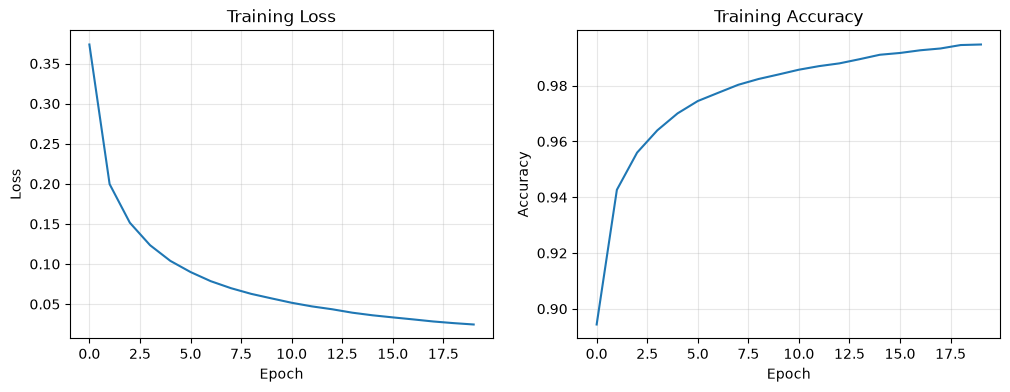

In [32]:
# Training Loop
#
# WHAT WE'RE DOING:
#   Show the model many digit images in small batches, again and again (epochs).
#   Each batch: forward → loss → backward → update weights.
#
# HYPERPARAMETERS (knobs):
#   hidden_size=128  → how wide the middle layer is
#   lr=0.1           → step size for weight updates
#   n_epochs=20      → how many full passes over the 56k training images
#   batch_size=64    → how many images per update (mini-batch SGD)
#
# WHAT THE PRINTS MEAN (each epoch):
#   Loss ↓     → predictions getting less wrong (good)
#   Accuracy ↑ → fraction of training images guessed correctly (good)
#
# WHAT THE PLOTS MEAN:
#   Left:  training loss should fall over epochs
#   Right: training accuracy should rise (often toward ~98%+ on MNIST)

input_size = 784   # 28*28 pixels
hidden_size = 128
output_size = 10   # digits 0–9
lr = 0.1
n_epochs = 20
batch_size = 64

model = TwoLayerNet(input_size, hidden_size, output_size)
n_samples = X_train.shape[0]
loss_history = []
acc_history = []

for epoch in range(n_epochs):
    # Shuffle so each epoch sees examples in a new order
    indices = np.random.permutation(n_samples)
    X_shuffled = X_train[indices]
    y_shuffled = y_train[indices]

    epoch_loss = 0.0
    correct = 0
    total = 0

    for start in range(0, n_samples, batch_size):
        end = start + batch_size
        X_batch = X_shuffled[start:end]
        y_batch = y_shuffled[start:end]

        # Forward: get 10 probabilities per image
        probs = model.forward(X_batch)
        loss = model.compute_loss(probs, y_batch)
        epoch_loss += loss * len(X_batch)

        # Predicted digit = class with highest probability
        preds = np.argmax(probs, axis=1)
        correct += np.sum(preds == y_batch)
        total += len(y_batch)

        # Backward + SGD step
        model.backward(y_batch)
        model.update_params(lr)

    avg_loss = epoch_loss / total
    accuracy = correct / total
    loss_history.append(avg_loss)
    acc_history.append(accuracy)
    print(f"Epoch {epoch+1:2d}/{n_epochs} | Loss: {avg_loss:.4f} | Accuracy: {accuracy:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(loss_history)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title('Training Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(acc_history)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.set_title('Training Accuracy')
ax2.grid(True, alpha=0.3)
plt.show()


Test Accuracy: 0.9758


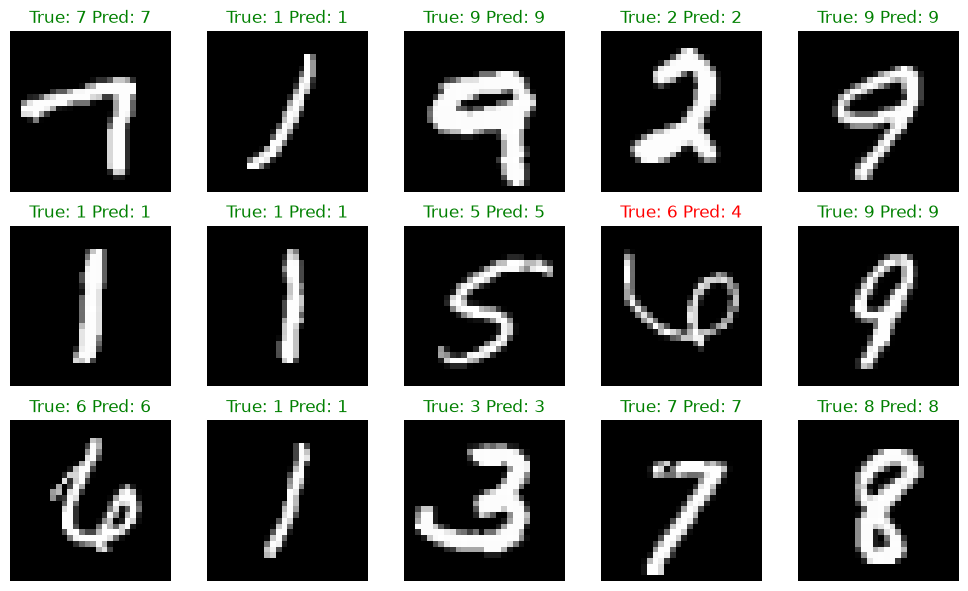

In [33]:
# Test Accuracy
#
# WHAT WE'RE DOING:
#   The model already practiced on X_train. Now give it the HELD-OUT quiz (X_test)
#   it never trained on — that measures real generalization.
#
# WHAT "Test Accuracy: 0.9756" MEANS:
#   About 97.56% of the 14,000 test images were labeled correctly.
#   (Still ~2.4% wrong — normal for this small 2-layer net.)
#
# THE IMAGE GRID:
#   Green title = guess matches true label
#   Red title   = mistake
#   Shows random test examples so you can SEE wins and fails.

probs_test = model.forward(X_test)
preds_test = np.argmax(probs_test, axis=1)          # pick best digit per image
test_accuracy = np.mean(preds_test == y_test)       # fraction correct
print(f"Test Accuracy: {test_accuracy:.4f}")

fig, axes = plt.subplots(3, 5, figsize=(10, 6))
for i, ax in enumerate(axes.flatten()):
    idx = np.random.randint(0, X_test.shape[0])
    ax.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    true_label = y_test[idx]
    pred_label = preds_test[idx]
    color = 'green' if true_label == pred_label else 'red'
    ax.set_title(f"True: {true_label} Pred: {pred_label}", color=color)
    ax.axis('off')
plt.tight_layout()
plt.show()

# You just trained a neural network on MNIST using only NumPy and your hand-derived gradients. 
# No PyTorch, no TensorFlow. This is what "understanding deep learning" means.

In [34]:
# PART 5: OPTIMIZERS & REGULARIZATION
#
# Optimizers decide HOW to apply gradients when updating weights.
#
#   SGD:      param -= lr * grad
#             simple, can be slow / zig-zag on ravines
#
#   Momentum: keep a velocity that remembers past grads
#             velocity = μ*velocity - lr*grad (μ - mean average)
#             param += velocity
#             → smoother, faster on valleys
#
#   Adam:     adapts step size per weight using running mean (m)
#             and mean-square (v) of gradients + bias correction
#             → usually converges faster / more stable (common default)

class Optimizer:
    def __init__(self, params):
        self.params = params  # list of Tensor weights/biases

    def zero_grad(self):
        for p in self.params:
            if isinstance(p, Tensor):
                p.grad = np.zeros_like(p.data)


class SGD(Optimizer):
    """Classic: take a step opposite the gradient."""
    def __init__(self, params, lr=0.01):
        super().__init__(params)
        self.lr = lr

    def step(self):
        for p in self.params:
            p.data -= self.lr * p.grad


class Momentum(Optimizer):
    """SGD + velocity (ball rolling downhill)."""
    def __init__(self, params, lr=0.01, momentum=0.9):
        super().__init__(params)
        self.lr = lr
        self.momentum = momentum
        self.velocities = [np.zeros_like(p.data) for p in self.params]

    def step(self):
        for i, p in enumerate(self.params):
            self.velocities[i] = self.momentum * self.velocities[i] - self.lr * p.grad
            p.data += self.velocities[i]


class Adam(Optimizer):
    """Adaptive per-parameter learning rates (very common in practice)."""
    def __init__(self, params, lr=0.001, betas=(0.9, 0.999), eps=1e-8):
        super().__init__(params)
        self.lr = lr
        self.beta1, self.beta2 = betas
        self.eps = eps
        self.m = [np.zeros_like(p.data) for p in self.params]  # 1st moment
        self.v = [np.zeros_like(p.data) for p in self.params]  # 2nd moment
        self.t = 0

    def step(self):
        self.t += 1
        for i, p in enumerate(self.params):
            g = p.grad
            self.m[i] = self.beta1 * self.m[i] + (1 - self.beta1) * g
            self.v[i] = self.beta2 * self.v[i] + (1 - self.beta2) * (g ** 2)
            # bias correction (important early in training)
            m_hat = self.m[i] / (1 - self.beta1 ** self.t)
            v_hat = self.v[i] / (1 - self.beta2 ** self.t)
            p.data -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)


Training TwoLayerNetAutograd with Adam...
Epoch 1/5 | Loss: 0.6503 | Train Acc: 0.8323
Epoch 2/5 | Loss: 0.2914 | Train Acc: 0.9181
Epoch 3/5 | Loss: 0.2262 | Train Acc: 0.9381
Epoch 4/5 | Loss: 0.1845 | Train Acc: 0.9483
Epoch 5/5 | Loss: 0.1551 | Train Acc: 0.9570

Test Accuracy (Adam + autograd): 0.9471
Compare: earlier NumPy SGD needed ~20 epochs for ~97%+ train acc;
Adam often gets into the mid/high 90s in just a few epochs.


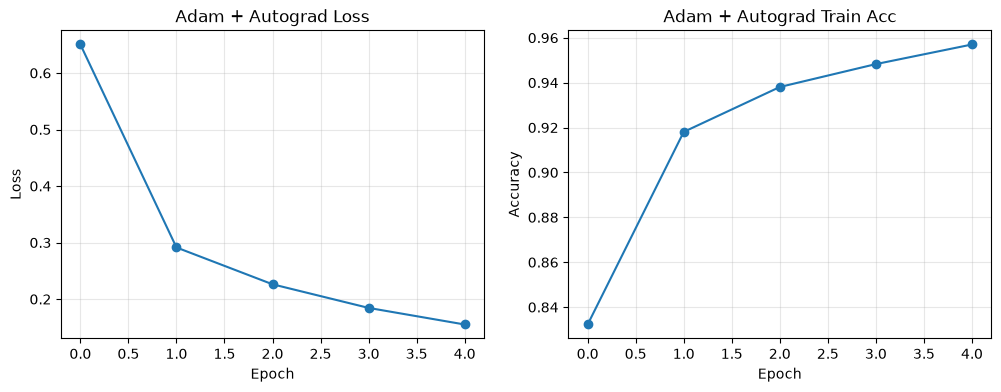

In [36]:
# Practice: TwoLayerNet with Tensors + Autograd, trained with Adam
#
# WHAT CHANGED vs the NumPy TwoLayerNet?
#   OLD: hand-written backward() for every layer
#   NEW: weights are Tensors → loss.backward() fills .grad automatically
#        then Adam.step() updates them
#
# WHY ADAM OFTEN FEELS "FASTER":
#   Adaptive steps per weight → reaches a good loss/accuracy in fewer epochs
#   than plain SGD (compare to the earlier 20-epoch NumPy SGD run).
#
# We use a training subset so the pure-Python autograd loop stays practical.

# Re-apply broadcast-safe +/* (needed for bias broadcasting in Linear)
def _reduce_grad(grad, shape):
    grad = np.asarray(grad, dtype=np.float64)
    while grad.ndim > len(shape):
        grad = grad.sum(axis=0)
    for axis, size in enumerate(shape):
        if size == 1 and grad.shape[axis] > 1:
            grad = grad.sum(axis=axis, keepdims=True)
    return grad.reshape(shape)

def _add_broadcast_safe(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(self.data + other.data, (self, other), '+',
                 requires_grad=self.requires_grad or other.requires_grad)
    def _backward():
        if self.requires_grad:
            self.grad += _reduce_grad(out.grad, self.data.shape)
        if other.requires_grad:
            other.grad += _reduce_grad(out.grad, other.data.shape)
    out._backward = _backward
    return out

def _mul_broadcast_safe(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(self.data * other.data, (self, other), '*',
                 requires_grad=self.requires_grad or other.requires_grad)
    def _backward():
        if self.requires_grad:
            self.grad += _reduce_grad(other.data * out.grad, self.data.shape)
        if other.requires_grad:
            other.grad += _reduce_grad(self.data * out.grad, other.data.shape)
    out._backward = _backward
    return out

Tensor.__add__ = _add_broadcast_safe
Tensor.__mul__ = _mul_broadcast_safe


class TwoLayerNetAutograd:
    """Same 784 → hidden → 10 net, but weights are Tensors (autograd)."""
    def __init__(self, input_size=784, hidden_size=128, output_size=10):
        self.net = Sequential(
            Linear(input_size, hidden_size),
            ReLU(),
            Linear(hidden_size, output_size),  # logits (no softmax here)
        )

    def forward(self, X_np):
        x = Tensor(X_np, requires_grad=False)
        return self.net.forward(x)  # (batch, 10) logits

    def parameters(self):
        return self.net.parameters()


# --- Train with Adam ---
np.random.seed(0)

# Subset for speed with Python autograd (still enough to see Adam shine)
n_subset = 15000
idx = np.random.permutation(X_train.shape[0])[:n_subset]
X_sub, y_sub = X_train[idx], y_train[idx]

model_ag = TwoLayerNetAutograd(784, 128, 10)
opt = Adam(model_ag.parameters(), lr=1e-3)

n_epochs = 5
batch_size = 128
n_samples = X_sub.shape[0]
loss_hist_adam, acc_hist_adam = [], []

print("Training TwoLayerNetAutograd with Adam...")
for epoch in range(n_epochs):
    perm = np.random.permutation(n_samples)
    X_s, y_s = X_sub[perm], y_sub[perm]
    epoch_loss, correct, total = 0.0, 0, 0

    for start in range(0, n_samples, batch_size):
        xb = X_s[start:start + batch_size]
        yb = y_s[start:start + batch_size]

        logits = model_ag.forward(xb)
        loss = cross_entropy_loss(logits, yb)

        opt.zero_grad()
        loss.backward()   # autograd fills W.grad, b.grad
        opt.step()        # Adam update

        epoch_loss += float(loss.data) * len(xb)
        preds = np.argmax(logits.data, axis=1)
        correct += np.sum(preds == yb)
        total += len(yb)

    avg_loss = epoch_loss / total
    acc = correct / total
    loss_hist_adam.append(avg_loss)
    acc_hist_adam.append(acc)
    print(f"Epoch {epoch+1}/{n_epochs} | Loss: {avg_loss:.4f} | Train Acc: {acc:.4f}")

# Quick test-set check
logits_te = model_ag.forward(X_test)
test_acc = np.mean(np.argmax(logits_te.data, axis=1) == y_test)
print(f"\nTest Accuracy (Adam + autograd): {test_acc:.4f}")
print("Compare: earlier NumPy SGD needed ~20 epochs for ~97%+ train acc;")
print("Adam often gets into the mid/high 90s in just a few epochs.")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(loss_hist_adam, marker='o')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title('Adam + Autograd Loss')
ax1.grid(True, alpha=0.3)
ax2.plot(acc_hist_adam, marker='o')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.set_title('Adam + Autograd Train Acc')
ax2.grid(True, alpha=0.3)
plt.show()


In [38]:
# PART 6: DROPOUT & BATCH NORMALIZATION 

# Dropout (from scratch)

def dropout_forward(X, p=0.5, training=True):
    if not training:
        return X
    mask = (np.random.rand(*X.shape) < p) / p
    return X * mask

# Example: during training, randomly drop neurons
X_batch = np.random.randn(64, 128)
dropped = dropout_forward(X_batch, p=0.5)
print("Fraction of zeros:", np.mean(dropped == 0))

# In a full framework, you'd store the mask to scale gradients during backward pass.

Fraction of zeros: 0.498291015625


In [42]:
# BatchNorm (conceptual implementation)

def batchnorm_forward(X, gamma, beta, eps=1e-5):
    mean = np.mean(X, axis=0)
    var = np.var(X, axis=0)
    X_hat = (X - mean) / np.sqrt(var + eps)
    out = gamma * X_hat + beta
    # Store for backward
    cache = (X, X_hat, mean, var, gamma, eps)
    return out, cache

# BatchNorm is crucial for training deep networks. The full backward pass is a bit hairy,
# but the key idea: normalize activations to have zero mean and unit variance,
# then scale and shift with learnable parameters.

In [44]:
summary_day4 = """
DAY 4 KEY INSIGHTS:

1. AUTOGRAD ENGINE:
   - Every operation records a _backward closure with local gradients
   - Backward() does topological sort then applies chain rule
   - Matrix multiply: dL/dA = dL/dC @ B^T, dL/dB = A^T @ dL/dC
   - Activation gradients: ReLU is a mask, sigmoid is s*(1-s)

2. LAYER ABSTRACTIONS:
   - Linear: Y = X @ W + b, gradients involve X.T and sums
   - ReLU: gradient is 1 where input > 0, else 0
   - Sequential: stacks layers, collects parameters

3. LOSS FUNCTIONS:
   - MSE for regression, Cross-Entropy for classification
   - Softmax + Cross-Entropy combined gradient: probs - one_hot(y)
   - Always use log-sum-exp trick for stability

4. TRAINING LOOP:
   - Forward pass -> compute loss -> zero grad -> backward -> update
   - Shuffle batches each epoch for better convergence
   - Track loss and accuracy to detect overfitting

5. OPTIMIZERS:
   - SGD: simplest, slow in ravines
   - Momentum: accelerates by accumulating velocity
   - Adam: adaptive per-parameter learning rates (first and second moments)

6. REGULARIZATION:
   - Dropout: randomly zeros neurons, acts as ensemble
   - BatchNorm: stabilizes training, allows higher learning rates
   - Weight decay (L2) and early stopping also key
"""
print(summary_day4)


DAY 4 KEY INSIGHTS:

1. AUTOGRAD ENGINE:
   - Every operation records a _backward closure with local gradients
   - Backward() does topological sort then applies chain rule
   - Matrix multiply: dL/dA = dL/dC @ B^T, dL/dB = A^T @ dL/dC
   - Activation gradients: ReLU is a mask, sigmoid is s*(1-s)

2. LAYER ABSTRACTIONS:
   - Linear: Y = X @ W + b, gradients involve X.T and sums
   - ReLU: gradient is 1 where input > 0, else 0
   - Sequential: stacks layers, collects parameters

3. LOSS FUNCTIONS:
   - MSE for regression, Cross-Entropy for classification
   - Softmax + Cross-Entropy combined gradient: probs - one_hot(y)
   - Always use log-sum-exp trick for stability

4. TRAINING LOOP:
   - Forward pass -> compute loss -> zero grad -> backward -> update
   - Shuffle batches each epoch for better convergence
   - Track loss and accuracy to detect overfitting

5. OPTIMIZERS:
   - SGD: simplest, slow in ravines
   - Momentum: accelerates by accumulating velocity
   - Adam: adaptive per-pa

In [45]:
# Challenge — Build a 3-Layer Net with Your Autograd Tensor
#
# GOAL:
#   Build 784 → 256 → 128 → 10 using Tensor + Sequential + ReLU + Adam + cross_entropy.
#   No hand-written backward for this net — loss.backward() does it.
#   Then compare speed/accuracy to a manual NumPy 3-layer with explicit backward.
#
# ARCHITECTURE (layers = processing stages, NOT data splits):
#   pixels (784)
#     → Linear 784→256 + ReLU
#     → Linear 256→128 + ReLU
#     → Linear 128→10   (logits)
#     → Cross-Entropy (softmax inside the loss)

# --- Broadcast-safe +/* for bias grads ---
def _reduce_grad(grad, shape):
    grad = np.asarray(grad, dtype=np.float64)
    while grad.ndim > len(shape):
        grad = grad.sum(axis=0)
    for axis, size in enumerate(shape):
        if size == 1 and grad.shape[axis] > 1:
            grad = grad.sum(axis=axis, keepdims=True)
    return grad.reshape(shape)

def _add_broadcast_safe(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(self.data + other.data, (self, other), '+',
                 requires_grad=self.requires_grad or other.requires_grad)
    def _backward():
        if self.requires_grad:
            self.grad += _reduce_grad(out.grad, self.data.shape)
        if other.requires_grad:
            other.grad += _reduce_grad(out.grad, other.data.shape)
    out._backward = _backward
    return out

def _mul_broadcast_safe(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(self.data * other.data, (self, other), '*',
                 requires_grad=self.requires_grad or other.requires_grad)
    def _backward():
        if self.requires_grad:
            self.grad += _reduce_grad(other.data * out.grad, self.data.shape)
        if other.requires_grad:
            other.grad += _reduce_grad(self.data * out.grad, other.data.shape)
    out._backward = _backward
    return out

Tensor.__add__ = _add_broadcast_safe
Tensor.__mul__ = _mul_broadcast_safe


# =============================================================================
# A) AUTOGRAD VERSION (Tensor + Module + Adam)
# =============================================================================
class ThreeLayerNetAutograd:
    """784 → 256 → 128 → 10 with Tensor weights (autograd)."""
    def __init__(self):
        self.net = Sequential(
            Linear(784, 256),
            ReLU(),
            Linear(256, 128),
            ReLU(),
            Linear(128, 10),  # logits
        )

    def forward(self, X_np):
        return self.net.forward(Tensor(X_np, requires_grad=False))

    def parameters(self):
        return self.net.parameters()


# =============================================================================
# B) MANUAL NUMPY VERSION (explicit backward) — for comparison
# =============================================================================
class ThreeLayerNetManual:
    """Same sizes, but gradients written by hand (like earlier TwoLayerNet)."""
    def __init__(self):
        self.W1 = np.random.randn(784, 256) * np.sqrt(2 / 784)
        self.b1 = np.zeros(256)
        self.W2 = np.random.randn(256, 128) * np.sqrt(2 / 256)
        self.b2 = np.zeros(128)
        self.W3 = np.random.randn(128, 10) * np.sqrt(2 / 128)
        self.b3 = np.zeros(10)
        self.params = [self.W1, self.b1, self.W2, self.b2, self.W3, self.b3]

    def forward(self, X):
        self.X = X
        self.z1 = X @ self.W1 + self.b1
        self.a1 = np.maximum(0, self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = np.maximum(0, self.z2)
        self.z3 = self.a2 @ self.W3 + self.b3
        shifted = self.z3 - np.max(self.z3, axis=1, keepdims=True)
        exp = np.exp(shifted)
        self.probs = exp / np.sum(exp, axis=1, keepdims=True)
        return self.probs

    def loss(self, probs, y):
        N = len(y)
        return -np.mean(np.log(probs[np.arange(N), y] + 1e-8))

    def backward(self, y):
        N = len(y)
        dz3 = self.probs.copy()
        dz3[np.arange(N), y] -= 1
        dz3 /= N
        dW3 = self.a2.T @ dz3
        db3 = dz3.sum(axis=0)
        da2 = dz3 @ self.W3.T
        dz2 = da2 * (self.z2 > 0)
        dW2 = self.a1.T @ dz2
        db2 = dz2.sum(axis=0)
        da1 = dz2 @ self.W2.T
        dz1 = da1 * (self.z1 > 0)
        dW1 = self.X.T @ dz1
        db1 = dz1.sum(axis=0)
        self.grads = [dW1, db1, dW2, db2, dW3, db3]

    def sgd_step(self, lr):
        for p, g in zip(self.params, self.grads):
            p -= lr * g


# =============================================================================
# Train both on the same subset / epochs and compare
# =============================================================================
import time

np.random.seed(0)
n_subset, n_epochs, batch_size = 12000, 5, 128
idx = np.random.permutation(X_train.shape[0])[:n_subset]
X_sub, y_sub = X_train[idx], y_train[idx]


def iterate_minibatches(X, y, bs):
    perm = np.random.permutation(len(y))
    X, y = X[perm], y[perm]
    for s in range(0, len(y), bs):
        yield X[s:s+bs], y[s:s+bs]


# --- Autograd + Adam ---
print("=" * 60)
print("A) 3-Layer AUTOGRAD + Adam")
print("=" * 60)
model_ag = ThreeLayerNetAutograd()
opt = Adam(model_ag.parameters(), lr=1e-3)
t0 = time.time()
for epoch in range(n_epochs):
    loss_sum, correct, total = 0.0, 0, 0
    for xb, yb in iterate_minibatches(X_sub, y_sub, batch_size):
        logits = model_ag.forward(xb)
        loss = cross_entropy_loss(logits, yb)
        opt.zero_grad()
        loss.backward()
        opt.step()
        loss_sum += float(loss.data) * len(yb)
        correct += np.sum(np.argmax(logits.data, axis=1) == yb)
        total += len(yb)
    print(f"  Epoch {epoch+1}/{n_epochs} | Loss {loss_sum/total:.4f} | Acc {correct/total:.4f}")
time_ag = time.time() - t0
test_ag = np.mean(np.argmax(model_ag.forward(X_test).data, axis=1) == y_test)
print(f"  Time: {time_ag:.1f}s | Test Acc: {test_ag:.4f}")


# --- Manual NumPy + SGD ---
print("\n" + "=" * 60)
print("B) 3-Layer MANUAL NumPy + SGD")
print("=" * 60)
np.random.seed(0)  # similar starting randomness scale (new weights though)
model_np = ThreeLayerNetManual()
lr_sgd = 0.1
t0 = time.time()
for epoch in range(n_epochs):
    loss_sum, correct, total = 0.0, 0, 0
    for xb, yb in iterate_minibatches(X_sub, y_sub, batch_size):
        probs = model_np.forward(xb)
        loss = model_np.loss(probs, yb)
        model_np.backward(yb)
        model_np.sgd_step(lr_sgd)
        loss_sum += loss * len(yb)
        correct += np.sum(np.argmax(probs, axis=1) == yb)
        total += len(yb)
    print(f"  Epoch {epoch+1}/{n_epochs} | Loss {loss_sum/total:.4f} | Acc {correct/total:.4f}")
time_np = time.time() - t0
test_np = np.mean(np.argmax(model_np.forward(X_test), axis=1) == y_test)
print(f"  Time: {time_np:.1f}s | Test Acc: {test_np:.4f}")


# --- Comparison table ---
print("\n" + "=" * 60)
print("COMPARISON")
print("=" * 60)
print(f"{'Method':<28} {'Time (s)':>10} {'Test Acc':>10}")
print("-" * 50)
print(f"{'Autograd + Adam':<28} {time_ag:>10.1f} {test_ag:>10.4f}")
print(f"{'Manual NumPy + SGD':<28} {time_np:>10.1f} {test_np:>10.4f}")
print("""
How to read this:
  - Autograd version: easier to write (no hand grads), usually SLOWER in pure Python
    because every op builds graph objects.
  - Manual NumPy: more code for backward, but raw array math is FASTER.
  - Adam often reaches higher accuracy in the same few epochs than plain SGD.
  - Real frameworks (PyTorch) get autograd convenience AND speed (C++/GPU).
""")


A) 3-Layer AUTOGRAD + Adam
  Epoch 1/5 | Loss 0.5751 | Acc 0.8372
  Epoch 2/5 | Loss 0.2134 | Acc 0.9391
  Epoch 3/5 | Loss 0.1508 | Acc 0.9556
  Epoch 4/5 | Loss 0.1052 | Acc 0.9707
  Epoch 5/5 | Loss 0.0746 | Acc 0.9793
  Time: 0.6s | Test Acc: 0.9539

B) 3-Layer MANUAL NumPy + SGD
  Epoch 1/5 | Loss 0.8020 | Acc 0.7823
  Epoch 2/5 | Loss 0.3513 | Acc 0.8986
  Epoch 3/5 | Loss 0.2808 | Acc 0.9180
  Epoch 4/5 | Loss 0.2373 | Acc 0.9310
  Epoch 5/5 | Loss 0.2066 | Acc 0.9402
  Time: 0.3s | Test Acc: 0.9309

COMPARISON
Method                         Time (s)   Test Acc
--------------------------------------------------
Autograd + Adam                     0.6     0.9539
Manual NumPy + SGD                  0.3     0.9309

How to read this:
  - Autograd version: easier to write (no hand grads), usually SLOWER in pure Python
    because every op builds graph objects.
  - Manual NumPy: more code for backward, but raw array math is FASTER.
  - Adam often reaches higher accuracy in the same fe